# D01 prompt ablation — analysis

This notebook summarizes JSONL outputs from [`research/eval/runner.py`](../eval/runner.py) produced by [`run_prompt_ablation.sh`](./run_prompt_ablation.sh).

**What stays outside this folder:** inference (HTTP `/infer`), prompt assembly, scoring rules — implemented in `runner.py` + `prompt_conditions.py`.

**What happens here:** load rows, sanity-check counts, reuse `runner.compute_summary` for parity with CLI summaries, and pivot by **`variant`** and **`prompt_condition`**.

**Important:** **`field_scores[..].label` / `hallucination_count`** (field-level judgments) differ from **`critical_label`** on the grounded deadline slot. The notebook exposes both — see §4–§7.

## 1. Environment

**On-device inference** (capturing JSONL yourself) requires the **iPhone eval setup** described in **[README.md](README.md)** under *Prerequisites* — `EVAL_MODE`, Xcode run to device, **`Eval server running on port 8080`**, and **`PHONE_IP`** for `/health`.

From repo root:

```bash
pip install -r research/prompt_ablation/requirements-notebook.txt
```

Imports below add `research/eval` to `sys.path` so we can reuse the harness **without copying** scoring code.

In [21]:
from __future__ import annotations

import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

def _repo_root(start: Path) -> Path:
    for p in [start] + list(start.parents):
        if (p / "research" / "eval" / "runner.py").is_file():
            return p
    raise RuntimeError(
        "Could not locate research/eval/runner.py. Launch Jupyter from the civics checkout "
        "(any subdirectory under it is OK)."
    )


NOTEBOOK_PATH = Path.cwd().resolve()
REPO_ROOT = _repo_root(NOTEBOOK_PATH)

EVAL_DIR = REPO_ROOT / "research" / "eval"
if str(EVAL_DIR) not in sys.path:
    sys.path.insert(0, str(EVAL_DIR))

from runner import compute_summary

print("REPO_ROOT:", REPO_ROOT)
print("EVAL_DIR:", EVAL_DIR)

REPO_ROOT: /Users/danfinkel/github/civics
EVAL_DIR: /Users/danfinkel/github/civics/research/eval


## 2. Prompt corpus (D01)

**Source:** [`research/eval/prompt_conditions.py`](../eval/prompt_conditions.py) — `PROMPT_ABLATION_VERSION` **2026-04-11**. User messages come from `build_extraction_prompt`; OCR + notice raster are appended on device. **`semantic-preview`** uses the **same extraction text** as **`semantic`**; Condition C differs in the eval app (notice-first preview pathway).

### `generic` (Condition A)

```
You are a document analysis assistant. Read the document carefully.

Extract information into the JSON object below. Use only information visible in the document.

Return ONLY valid JSON with exactly these keys. No markdown fences, no commentary.

{
  "document_type": "",
  "holder_name": "",
  "key_date": "",
  "secondary_date": "",
  "key_amount_or_address": "",
  "any_id_or_case_number": "",
}

For any field you cannot read clearly, set its value to UNREADABLE.

```

### `semantic` / `semantic-preview` extraction body (Conditions B/C)

```
You are a document analysis assistant for a Massachusetts civic benefits notice.

Rules:
- Extract only values clearly present in the document.
- Read each field from its labeled location in the notice.
- For date fields: use semantic labels as requested in the JSON keys (e.g. notice_date vs response_deadline). Do not swap due dates with notice dates.
- Copy names character-by-character as printed.
- If you cannot read a field, set its value to UNREADABLE.
- Return ONLY valid JSON with exactly these keys. No markdown.

{
  "notice_date": "",
  "response_deadline": "",
  "requested_category": "",
  "consequence": "",
  "caseworker_name": "",
  "case_number": "",
  "recipient_name": "",
}

```

For the **critical deadline** scoring field see `critical_deadline_key`: **`generic` → `key_date`**, **`semantic`/`semantic-preview` → `response_deadline`**.


## 3. Input paths

- **One file:** set a single path (e.g. generic-only run).
- **Compare conditions:** extend the list — each file adds rows (`prompt_condition` in the payload tells them apart).

In [22]:
# Lab assets live next to this notebook (standalone folder).
LAB_DIR = (
    NOTEBOOK_PATH
    if (NOTEBOOK_PATH / "run_prompt_ablation.sh").is_file()
    else REPO_ROOT / "research" / "prompt_ablation"
)
RESULTS_DIR = LAB_DIR / "results"

# Edit timestamps here; uncomment more files to stack prompt conditions.
JSONL_PATHS = [
    RESULTS_DIR / "ablation_generic_20260412_notebook_rescored_v4.jsonl",
    # RESULTS_DIR / "ablation_generic_20260412_notebook.jsonl",    
    # RESULTS_DIR / "ablation_semantic_YYYYMMDD_HHMM.jsonl",
    # RESULTS_DIR / "ablation_semantic_preview_YYYYMMDD_HHMM.jsonl",
]
JSONL_PATHS = [p for p in JSONL_PATHS if p.exists()]
if not JSONL_PATHS:
    raise FileNotFoundError(
        f"No JSONL found under {RESULTS_DIR}. "
        "Copy artifacts here or adjust JSONL_PATHS in this cell."
    )

JSONL_PATHS

[PosixPath('/Users/danfinkel/github/civics/research/prompt_ablation/results/ablation_generic_20260412_notebook_rescored_v4.jsonl')]

## 4. Row schema (runner JSONL)

Each line is one **Monte Carlo** call. Important keys:

| Key | Meaning |
|-----|--------|
| `artifact_id`, `variant`, `track`, `run` | Design grid identifiers |
| `prompt_condition` | `generic`, `semantic`, or `semantic-preview` |
| `field_scores` | Per-field `label` + `score` (**many slots can read as `hallucinated`**) |
| `hallucination_count` | Number of scored fields whose `field_scores[..].label` is **`hallucinated`** |
| **`critical_*`** | **Separate** judgment for **one** grounded slot (deadline): `critical_field`, `critical_label`, `critical_extracted`. Often **`misattribution`** or **`exact`** even when **`key_date`** (or similar) inside `field_scores` is **`hallucinated`** — so eyeballing the JSON for `hallucinated` does **not** match **`critical_label == "hallucinated"`**. |
| `elapsed_ms`, `parse_ok`, `temperature` | Throughput / validity |

Exact scoring rules: see `research/eval/runner.py` and `score_field` helpers.

In [23]:
def load_jsonl(path: Path) -> list[dict]:
    rows: list[dict] = []
    with path.open(encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            rows.append(json.loads(line))
    return rows


def field_halluc_fraction(row: dict) -> float:
    fs = row.get("field_scores") or {}
    if not fs:
        return float("nan")
    labs = [v.get("label") for v in fs.values() if isinstance(v, dict)]
    if not labs:
        return float("nan")
    return sum(1 for lb in labs if lb == "hallucinated") / len(labs)


all_rows: list[dict] = []
for p in JSONL_PATHS:
    chunk = load_jsonl(p)
    for r in chunk:
        r["_source_jsonl"] = str(p.resolve())
        r["_field_halluc_frac"] = field_halluc_fraction(r)
    all_rows.extend(chunk)

df = pd.json_normalize(all_rows)
len(all_rows), df.shape

(80, (80, 44))

## 5. Harness-level summary (`compute_summary`)

Matches aggregates used by [`generate_agent4_summary.py`](../eval/generate_agent4_summary.py).

**`hallucination_rate`** pools **every** `field_scores[..].label` across all rows (fraction labeled **`hallucinated`**). That matches “lots of `hallucinated` in the JSON” more than **`critical_label`** alone — see §4.

In [24]:
summary = compute_summary(all_rows)
pd.Series(summary).sort_index()

avg_score_mean                                                                   -0.16665
avg_score_std                                                                    0.485924
exact_rate                                                                       0.208333
field_label_counts                      {'exact': 100, 'partial': 0, 'format_mismatch'...
field_label_rate_exact                                                           0.208333
field_label_rate_format_mismatch                                                      0.0
field_label_rate_hallucinated                                                       0.375
field_label_rate_misattribution                                                  0.208333
field_label_rate_missing                                                              0.0
field_label_rate_partial                                                              0.0
field_label_rate_semantic_paraphrase                                             0.083333
field_labe

In [25]:
df.iloc[0]

artifact_id                                                                                       D01
variant                                                                                         clean
track                                                                                               a
run                                                                                                 0
temperature                                                                                       0.0
token_budget                                                                                     None
elapsed_ms                                                                                       3882
parse_ok                                                                                         True
error                                                                                            None
raw_response                                        {\n  "document_type": "Loan Ag

## 6. Pivots — variant × prompt condition

Standard ablation uses **artifacts=D01**, **runs=20** per `(variant × condition)` (~80 rows per JSONL for four variants).

**Two “hallucination” views:**
- **`mean_field_halluc_frac`** — mean over runs of `(# fields labeled hallucinated) / (# fields scored)`. Aligns with skimming **`field_scores`** / **`hallucination_count`** and with **`compute_summary`**’s pooled rate.
- **`critical_halluc_frac`** — fraction of runs where **`critical_label == "hallucinated"`** (strict fabrication on the mapped deadline slot only; often **0** when **`field_scores`** still show **`hallucinated`** elsewhere).

**`critical_misattribution_frac`** is the analogous fraction for **`critical_label == "misattribution"`** (common on blurrier tracks).

In [26]:
def critical_acceptable(labels: pd.Series) -> pd.Series:
    ok = {
        "exact",
        "partial",
        "format_mismatch",
        "transcription_error",
        "semantic_paraphrase",
        "verbatim_quote",
    }
    return labels.isin(ok)


if "_field_halluc_frac" not in df.columns:
    raise RuntimeError("_field_halluc_frac missing — re-run load cell")


gcols = [c for c in ["prompt_condition", "variant"] if c in df.columns]
_cl = df["critical_label"].astype(str) if "critical_label" in df.columns else pd.Series("", index=df.index)

tmp = df.assign(
    _crit_ok=critical_acceptable(_cl),
    _crit_is_halluc=_cl == "hallucinated",
    _crit_is_misattrib=_cl == "misattribution",
)

grp = (
    tmp.groupby(gcols)
    .agg(
        rows=("run", "count"),
        parse_ok_rate=("parse_ok", lambda s: float(s.astype(bool).mean())),
        critical_halluc_frac=("_crit_is_halluc", "mean"),
        critical_misattribution_frac=("_crit_is_misattrib", "mean"),
        mean_field_halluc_frac=("_field_halluc_frac", "mean"),
        mean_halluc_count=("hallucination_count", "mean"),
        acceptable_critical=("_crit_ok", "mean"),
        mean_latency_ms=("elapsed_ms", "mean"),
        mean_avg_score=("avg_score", "mean"),
    )
    .reset_index()
)

if "critical_field" in df.columns:
    _cf = df.groupby(gcols)["critical_field"].first().reset_index()
    grp = grp.merge(_cf, on=gcols, how="left")

grp.round(5)

,prompt_condition,variant,rows,parse_ok_rate,critical_halluc_frac,critical_misattribution_frac,mean_field_halluc_frac,mean_halluc_count,acceptable_critical,mean_latency_ms,mean_avg_score,critical_field
0,generic,blurry,20,1.0,0.0,0.0,0.33333,2.0,1.0,6000.35,0.0000,key_date
1,generic,clean,20,1.0,0.0,1.0,0.83333,5.0,0.0,3464.50,-1.0000,key_date
2,generic,clean_jpeg,20,1.0,0.0,0.0,0.16667,1.0,1.0,8073.75,0.1667,key_date
3,generic,degraded,20,1.0,0.0,0.0,0.16667,1.0,1.0,7281.90,0.1667,key_date


## 7. Charts

Bars plot **`mean_field_halluc_frac`** (%) — comparable to **`hallucination_count`** when scanning **`field_scores`**. Use the pivot columns **`critical_*_frac`** for deadline-slot breakdowns only.

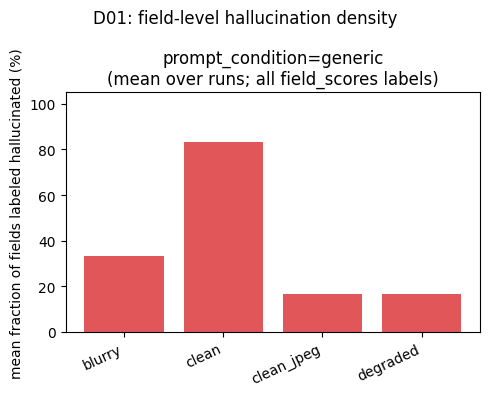

In [27]:
_plotdf = grp.copy()
_plotdf["field_halluc_pct"] = 100 * _plotdf["mean_field_halluc_frac"]

conds = sorted(_plotdf["prompt_condition"].dropna().unique())
if not len(_plotdf["variant"].dropna().unique()):
    raise RuntimeError("No variants to plot")

fig, axes = plt.subplots(1, max(1, len(conds)), figsize=(5 * max(1, len(conds)), 4), squeeze=False)
for ax_row, pc in enumerate(conds):
    ax = axes[0][ax_row]
    sub = _plotdf[_plotdf["prompt_condition"] == pc]
    xv = range(len(sub))
    ax.bar(xv, sub["field_halluc_pct"].tolist(), color="#e15759")
    ax.set_xticks(list(xv), sub["variant"].tolist(), rotation=25, ha="right")
    ax.set_ylim(0, 105)
    ax.set_ylabel("mean fraction of fields labeled hallucinated (%)")
    ax.set_title(f"prompt_condition={pc}\n(mean over runs; all field_scores labels)")
fig.suptitle("D01: field-level hallucination density")
plt.tight_layout()
plt.show()

## 8. Optional — write Markdown summary

For a fuller narrative PDF/Kaggle artifact, delegate to **`generate_agent4_summary.py`** (handles multi-file merges and richer sections).

```bash
cd research/eval
python3 generate_agent4_summary.py \
  ../prompt_ablation/results/ablation_generic_STAMP.jsonl \
  ../prompt_ablation/results/ablation_semantic_STAMP.jsonl \
  ../prompt_ablation/results/ablation_semantic_preview_STAMP.jsonl \
  -o ../prompt_ablation/results/summary_STAMP.md
```